<a href="https://colab.research.google.com/github/hanyuchen0404-sherry/RFM-Analysis/blob/main/RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Title
## Second Title
- item 1
- item 2
- item 3
**abcde

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('RFM.csv')

In [ ]:
df.head()

,Date,InvoNo,CustomerKey,銷售金額
0,20180413,AP1804933,A1255,9997.02
1,20180423,AP1807826,A1188,9997.02
2,20180424,AP1800872,A0846,9997.02
3,20180426,AP1803170,A1204,9997.02
4,20180501,MA1806692,A0907,9997.02


In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# 1. 日期格式轉換與基準日設定
# ==========================================
# 將 'Date' 欄位轉為字串後，再以 pd.to_datetime 解析（相容文字如 '2018-01-01' 或整數如 20180101）
df['Date'] = pd.to_datetime(df['Date'].astype(str))

# 找出整個 sales 資料集中的最晚日期作為計算基準日
reference_date = df['Date'].max()

# ==========================================
# 2. 聚合計算 R, F, M
# ==========================================
df_rfm_agg = (
    df.groupby('CustomerKey')
    .agg(
        # Recency: 基準日 減去 該客戶最後一次消費日期的天數差
        Recency=('Date', lambda x: (reference_date - x.max()).days),
        # Frequency: 發票編號相異值計數
        Frequency=('InvoNo', 'nunique'),
        # Monetary: 銷售金額加總
        Monetary=('銷售金額', 'sum'),
    )
    .reset_index()
)

# ==========================================
# 3. 資料複製
# ==========================================
df_rfm = df_rfm_agg.copy()

# ==========================================
# 4. RFM 評分 (1-5 分，使用 pd.qcut)
# ==========================================
# 注意：
# - 使用 .rank(method='first') 可避免切分區間邊界重複 (Bin edges must be unique) 的錯誤
# - Recency: 天數越小代表越近消費，分數越高 (labels=[5, 4, 3, 2, 1])
# - Frequency & Monetary: 數值越大分數越高 (labels=[1, 2, 3, 4, 5])

df_rfm['R_Score'] = (
    pd.qcut(
        df_rfm['Recency'].rank(method='first'),
        q=5,
        labels=[5, 4, 3, 2, 1],
    )
    .astype(int)
)

df_rfm['F_Score'] = (
    pd.qcut(
        df_rfm['Frequency'].rank(method='first'),
        q=5,
        labels=[1, 2, 3, 4, 5],
    )
    .astype(int)
)

df_rfm['M_Score'] = (
    pd.qcut(
        df_rfm['Monetary'].rank(method='first'),
        q=5,
        labels=[1, 2, 3, 4, 5],
    )
    .astype(int)
)

# ==========================================
# 5. 客群標籤 (RFM_Segment) 劃分邏輯
# ==========================================
# 建立分群規則（順序由高優先權往低判定）：
conditions = [
    # 高價值核心客戶：近期有買、常買、花得多
    (df_rfm['R_Score'] >= 4) & (df_rfm['F_Score'] >= 4) & (df_rfm['M_Score'] >= 4),

    # 忠誠客戶：近期活躍且頻次高
    (df_rfm['R_Score'] >= 3) & (df_rfm['F_Score'] >= 3),

    # 潛力客戶 / 新客：近期有消費，但累積頻次尚低
    (df_rfm['R_Score'] >= 4) & (df_rfm['F_Score'] <= 2),

    # 重要留存客戶 (流失風險高)：過去常買或貢獻高，但近期很久沒來
    (df_rfm['R_Score'] <= 2) & ((df_rfm['F_Score'] >= 3) | (df_rfm['M_Score'] >= 4)),

    # 流失 / 沉睡客戶：很久沒買且以前頻次也不高
    (df_rfm['R_Score'] <= 2) & (df_rfm['F_Score'] <= 2),
]

segment_names = [
    '高價值客戶 (Champions)',
    '忠誠客戶 (Loyal Customers)',
    '潛力客戶 (Potential)',
    '重要留存客戶 (At Risk)',
    '流失/沉睡客戶 (Lost)',
]

# 套用條件標籤，未吻合者歸類為一般客戶
df_rfm['RFM_Segment'] = np.select(conditions, segment_names, default='一般維護客戶 (Others)')



import pandas as pd

# 1. 調整 Pandas 全域設定：確保 print 時一定會折疊並顯示欄列數資訊
pd.set_option('display.max_rows', 10)       # 超過10列就折疊
pd.set_option('display.show_dimensions', True) # 關鍵：強制 print 時一定要印出 [X rows x Y columns]

# 2. 抽取核心欄位並複製
result_df = df_rfm[['CustomerKey', 'Frequency', 'Monetary', 'Recency']].copy()

# 3. 修改欄位名稱完全對齊老師
result_df.columns = ['Customer', 'F', 'M', 'R']

# 4. 確保 F 和 R 顯示為整數
result_df['F'] = result_df['F'].astype(int)
result_df['R'] = result_df['R'].astype(int)

# 5. 印出結果 (這樣就會包含中間的 ...、末尾的 727-731 以及最底下的行列數提示)
print(result_df)


print()
import pandas as pd

# 1. 調整環境設定（確保 8 個欄位能橫向併排，不折行、不漏字）
pd.set_option('display.max_rows', 10)          # 超過 10 列就自動折疊中間
pd.set_option('display.max_columns', None)     # 完整顯示所有欄位
pd.set_option('display.width', 1000)           # 拓寬字元限制，防止表格斷行
pd.set_option('display.show_dimensions', True) # 顯示最底下的 [732 rows x 8 columns]

# 2. 只印出你原本算好的完整資料表
print(df_rfm)


    Customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]

    CustomerKey  Recency  Frequency     Monetary  R_Score  F_Score  M_Score             RFM_Segment
0         A0350        9         25  51238.11440        5        5        4       高價值客戶 (Champions)
1         A0351       16          6  17890.31200        4        2        3        潛力客戶 (Potential)
2         A0352       14         14  46424.03852        4        3        4  忠誠客戶 (Loyal Customers)
3         A0353       24         14  27607.68636        3        3        3  忠誠客戶 (Loyal Customers)
4         A0354       31          6   9973.92064        3        2 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 查看各客群的客戶數佔比與平均指標
segment_summary = df_rfm.groupby('RFM_Segment').agg(
    客戶數=('CustomerKey', 'count'),
    平均Recency=('Recency', 'mean'),
    平均Frequency=('Frequency', 'mean'),
    平均Monetary=('Monetary', 'mean')
).reset_index()

# 關鍵：使用 style 來做真正的網頁級置中對齊，並四捨五入小數點後 2 位（看起來更乾淨）
segment_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]}
]).format({
    '平均Recency': '{:.2f}',
    '平均Frequency': '{:.2f}',
    '平均Monetary': '{:.2f}'
})

,RFM_Segment,客戶數,平均Recency,平均Frequency,平均Monetary
0,一般維護客戶 (Others),44,26.05,4.48,11702.51
1,忠誠客戶 (Loyal Customers),183,16.64,16.02,40341.82
2,流失/沉睡客戶 (Lost),201,108.76,4.01,9243.18
3,潛力客戶 (Potential),44,10.16,4.61,12515.68
4,重要留存客戶 (At Risk),92,64.23,13.32,36320.53
5,高價值客戶 (Champions),168,8.43,23.92,61183.75


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import os

# 1. 確保 df_rfm 存在於記憶體中，若不存在，則自動從 Google Drive 或本地加載 RFM.csv 並重新計算
if 'df_rfm' not in locals():
    # 定義可能存在的路徑
    possible_paths = [
        '/content/drive/MyDrive/RFM.csv',
        'drive/MyDrive/RFM.csv',
        '/content/RFM.csv',
        'RFM.csv'
    ]
    csv_path = None
    for path in possible_paths:
        if os.path.exists(path):
            csv_path = path
            break

    if csv_path is not None:
        df = pd.read_csv(csv_path)
        df['Date'] = pd.to_datetime(df['Date'].astype(str))
        reference_date = df['Date'].max()
        df_rfm = (
            df.groupby('CustomerKey')
            .agg(
                Recency=('Date', lambda x: (reference_date - x.max()).days),
                Frequency=('InvoNo', 'nunique'),
                Monetary=('銷售金額', 'sum'),
            )
            .reset_index()
        )
    else:
        raise FileNotFoundError("在預期路徑中皆找不到 'RFM.csv'。請確認檔案是否確實上傳到左側檔案區或雲端硬碟中。")

# 2. 進行 Min-Max 正規化
scaler = MinMaxScaler()
norm_features = scaler.fit_transform(df_rfm[['Recency', 'Frequency', 'Monetary']])

# 3. 建立新的 DataFrame nrfm 並命名欄位
nrfm = pd.DataFrame(norm_features, columns=['R_Norm', 'F_Norm', 'M_Norm'])
nrfm.insert(0, 'CustomerKey', df_rfm['CustomerKey'])

# 4. 使用 KMeans 進行分群 (n_clusters=4) 並將結果寫入 Cluster 欄位
k=4
kmeans = KMeans(n_clusters=k, random_state=42)
nrfm['Cluster'] = kmeans.fit_predict(nrfm[['R_Norm', 'F_Norm', 'M_Norm']])

# 5. 印出結果前 5 列
display(nrfm.head())

,CustomerKey,R_Norm,F_Norm,M_Norm,Cluster
0,A0350,0.024523,0.631579,0.376563,1
1,A0351,0.043597,0.131579,0.127866,3
2,A0352,0.038147,0.342105,0.340662,2
3,A0353,0.065395,0.342105,0.200335,2
4,A0354,0.084469,0.131579,0.068827,3


In [9]:
kmeans.labels_

array([1, 3, 2, 2, 3, 3, 3, 2, 3, 3, 0, 3, 2, 3, 2, 2, 3, 1, 0, 1, 0, 2,
       2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 0, 2, 3, 3, 3, 1, 3, 3, 2, 1, 2, 2,
       0, 3, 2, 3, 3, 1, 3, 0, 3, 2, 1, 1, 2, 0, 3, 0, 3, 2, 2, 3, 3, 2,
       1, 3, 3, 2, 0, 3, 3, 3, 2, 2, 2, 0, 1, 2, 1, 3, 3, 2, 2, 2, 2, 3,
       3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 3,
       3, 3, 2, 1, 2, 2, 3, 2, 2, 3, 2, 3, 3, 2, 1, 2, 1, 2, 3, 3, 3, 2,
       3, 3, 0, 1, 1, 0, 2, 3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 1, 3, 2,
       1, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 1, 0, 1, 3, 2,
       1, 3, 0, 3, 3, 0, 2, 1, 1, 1, 2, 3, 3, 3, 3, 1, 3, 2, 0, 3, 0, 0,
       1, 2, 2, 1, 3, 3, 2, 0, 3, 2, 3, 0, 1, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       1, 3, 2, 2, 3, 2, 3, 2, 2, 3, 3, 2, 1, 3, 3, 3, 3, 1, 3, 1, 3, 0,
       2, 2, 3, 3, 0, 0, 1, 3, 0, 0, 2, 3, 0, 3, 1, 1, 2, 2, 3, 2, 2, 3,
       1, 3, 3, 3, 2, 1, 2, 1, 1, 3, 3, 3, 0, 2, 3, 2, 2, 3, 3, 3, 1, 3,
       3, 2, 3, 3, 3, 3, 2, 2, 2, 3, 2, 2, 1, 2, 1,

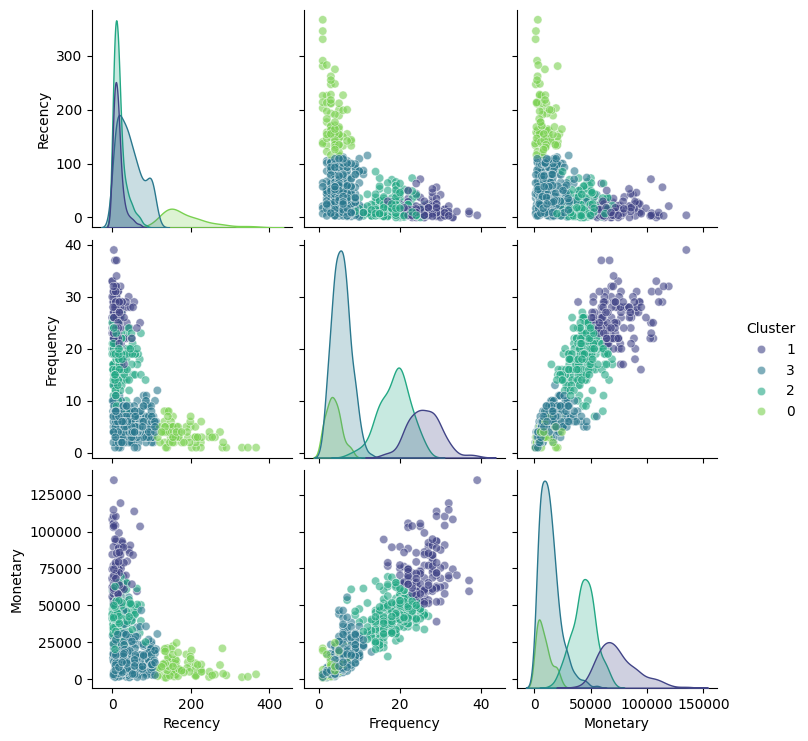

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 將 nrfm 中的 'Cluster' 欄位合併回擁有原始數值的 df_rfm 中
# 確保 df_rfm 裡有最新對齊的 Cluster 欄位
if 'Cluster' in df_rfm.columns:
    df_rfm = df_rfm.drop(columns=['Cluster'])
df_rfm_clustered = df_rfm.merge(nrfm[['CustomerKey', 'Cluster']], on='CustomerKey', how='left')

# 2. & 3. 使用 sns.pairplot 繪製成對散佈圖，並根據 'Cluster' 分群顯示顏色
# 這裡我們將 'Cluster' 欄位轉為類別型態，以防繪圖時將群別當成連續數值漸層顯示
df_rfm_clustered['Cluster'] = df_rfm_clustered['Cluster'].astype(str)

# 挑選要繪圖的欄位
plot_cols = ['Recency', 'Frequency', 'Monetary', 'Cluster']
g = sns.pairplot(
    df_rfm_clustered[plot_cols],
    hue='Cluster',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

# 4. 將成對散佈圖儲存為檔案 RFM_Pairplot.png
plt.savefig('RFM_Pairplot.png', dpi=300, bbox_inches='tight')

# 5. 顯示圖片
plt.show()

In [8]:
import pandas as pd

# 1. 建立群組對應字典，並將 nrfm 的 Cluster 資訊對應後新增為 df_rfm 的 'Group' 欄位
cluster_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 確保 df_rfm 中有最新分群資訊
if 'Cluster' in df_rfm.columns:
    df_rfm = df_rfm.drop(columns=['Cluster'])

# 先合併 Cluster 數值，再進行對應轉換
df_rfm = df_rfm.merge(nrfm[['CustomerKey', 'Cluster']], on='CustomerKey', how='left')
df_rfm['Group'] = df_rfm['Cluster'].map(cluster_mapping)

# 2. 將包含完整欄位與新群組標籤的資料表匯出為 CSV 檔
df_rfm.to_csv('RFM_result.csv', index=False, encoding='utf-8-sig')

# 3. 檢查前 5 列成果
display(df_rfm.head())

,CustomerKey,Recency,Frequency,Monetary,Cluster,Group
0,A0350,9,25,51238.11440,1,High
1,A0351,16,6,17890.31200,3,Medium
2,A0352,14,14,46424.03852,2,Low
3,A0353,24,14,27607.68636,2,Low
4,A0354,31,6,9973.92064,3,Medium


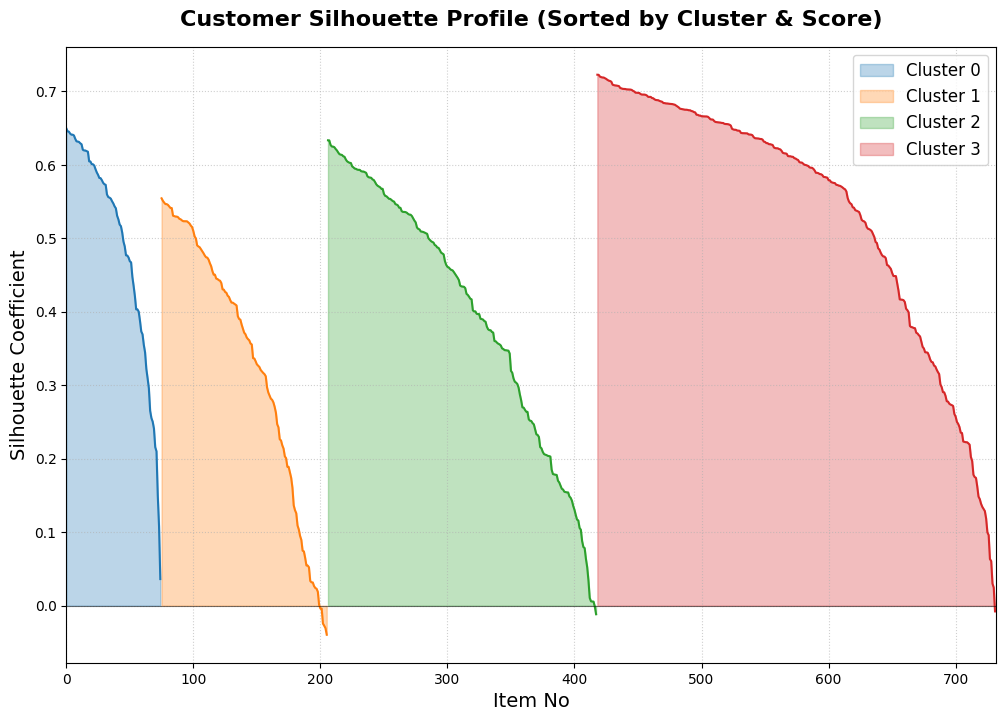

In [22]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# 1. & 2. 計算每個客戶的獨立輪廓值並新增為 'Sil_Score' 欄位
features = nrfm[['R_Norm', 'F_Norm', 'M_Norm']]
labels = nrfm['Cluster']
nrfm['Sil_Score'] = silhouette_samples(features, labels)

# 3. 關鍵排序步驟：依照 Cluster 升冪排序，在同 Cluster 內再依照 Sil_Score 降冪排序
nrfm_sorted = nrfm.sort_values(by=['Cluster', 'Sil_Score'], ascending=[True, False])

# 4. 重設索引，重設後的索引即為 'Item No'
nrfm_sorted = nrfm_sorted.reset_index(drop=True)

# 5. 繪製個體輪廓值排序分佈圖
plt.figure(figsize=(12, 8))

# 定義 4 個群組對應的填滿顏色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 依群組別分段繪製 fill_between
for i in range(4):
    # 篩選出該群組的資料子集
    group_mask = nrfm_sorted['Cluster'] == i
    group_data = nrfm_sorted[group_mask]

    # 取得該群組在排序後資料表中的索引範圍（Item No）與對應的輪廓分數
    x_indices = group_data.index
    y_values = group_data['Sil_Score']

    # 繪製該群組的輪廓值折線與區域填滿
    plt.plot(x_indices, y_values, color=colors[i], linewidth=1.5)
    plt.fill_between(x_indices, y_values, 0, color=colors[i], alpha=0.3, label=f'Cluster {i}')

# 6. 設定圖表細節與標籤
plt.xlim(0, len(nrfm_sorted))
plt.title('Customer Silhouette Profile (Sorted by Cluster & Score)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Item No', fontsize=14)
plt.ylabel('Silhouette Coefficient', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5) # 繪製 0 基準線
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=12)

# 7. 儲存圖片並顯示
plt.savefig('Teacher_Silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

For n_clusters = 4, the average silhouette_score is: 0.4561


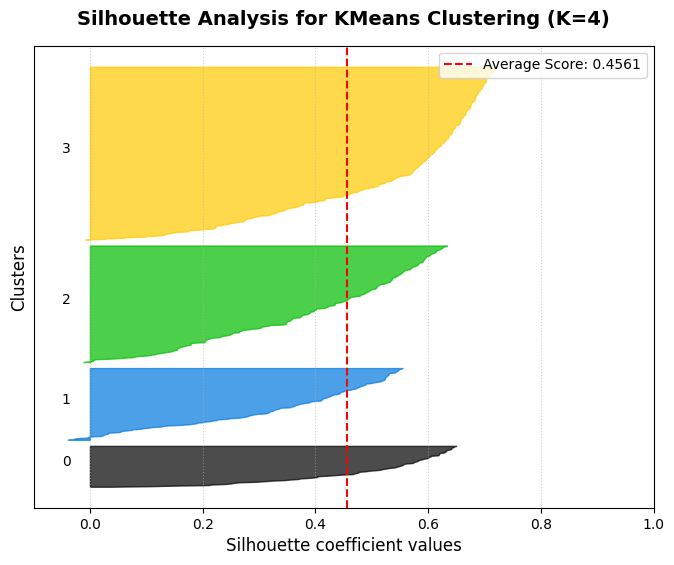

In [11]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 2. 定義特徵矩陣與分群標籤
X = nrfm[['R_Norm', 'F_Norm', 'M_Norm']]
labels = nrfm['Cluster']
n_clusters = 4

# 3. 計算整體的平均輪廓分數並印出
silhouette_avg = silhouette_score(X, labels)
print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.4f}")

# 計算每個樣本的輪廓分數
sample_silhouette_values = silhouette_samples(X, labels)

# 4. 繪製標準的輪廓圖
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
for i in range(n_clusters):
    # 彙整並排序第 i 個群組的樣本輪廓分數
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # 使用 matplotlib.cm 設定群組顏色
    color = cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    # 在各群組輪廓的中間位置標示群組標籤 (0, 1, 2, 3)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # 計算下一個群組的起點位置，留下一點間隔
    y_lower = y_upper + 10

# 調整圖表樣式與標籤
ax.set_title('Silhouette Analysis for KMeans Clustering (K=4)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Silhouette coefficient values', fontsize=12)
ax.set_ylabel('Clusters', fontsize=12)

# 繪製一條紅色虛線代表整體的平均輪廓分數
ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Average Score: {silhouette_avg:.4f}')

# 整理軸刻度
ax.set_yticks([])  # 清除 y 軸刻度數字，因為已在圖內手動標示
ax.set_xlim([-0.1, 1.0])
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

# 5. 儲存圖片並顯示
plt.savefig('RFM_Silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(df_rfm[["Recency","Frequency","Monetary"]],df_rfm.Cluster)

Text(0.5, 0, 'Item No')

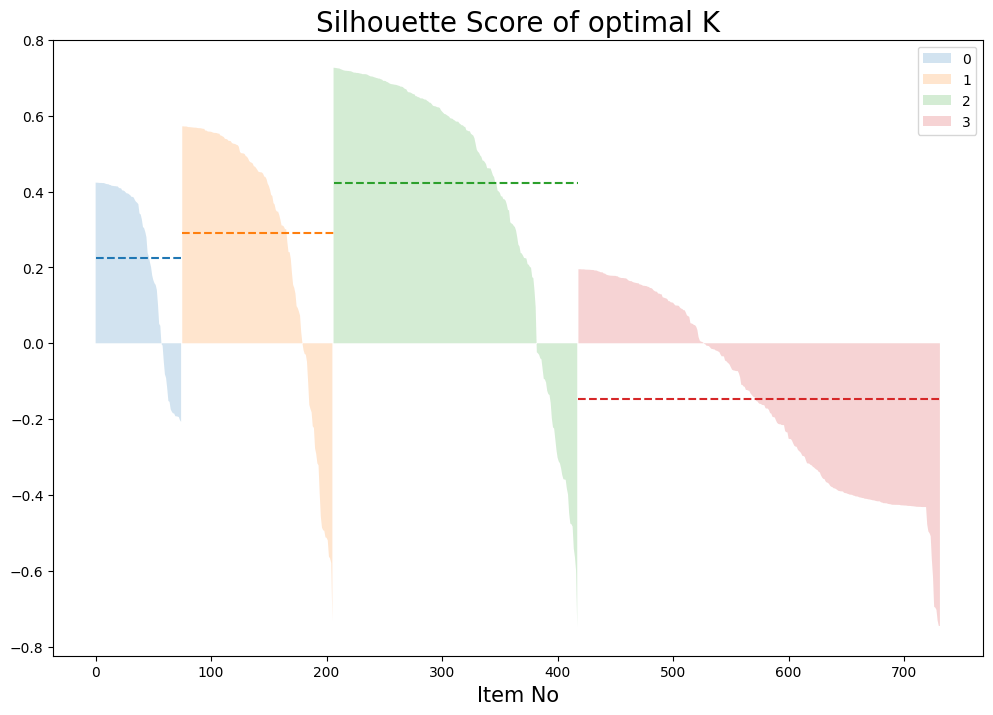

In [21]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):

    group_slh=silhouette[df_rfm.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿

    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線

    plt.legend() # 繪製圖例

    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

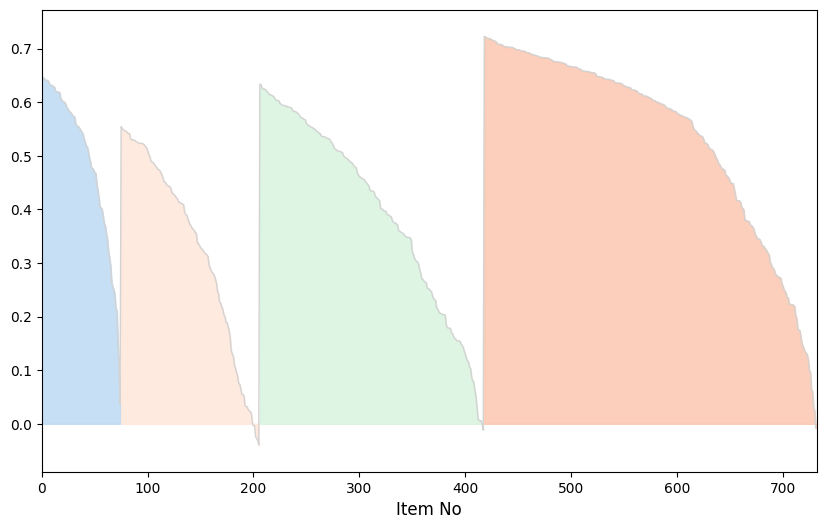

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_samples

# ==========================================
# 1. 計算每個客戶獨立的輪廓值 (Silhouette Sample Value)
# ==========================================
features = nrfm[["R_Norm", "F_Norm", "M_Norm"]]
labels = nrfm["Cluster"]

# 計算出 732 個人的獨立分數並寫入表格
nrfm["Sil_Score"] = silhouette_samples(features, labels)

# ==========================================
# 2. 關鍵排序：先依 Cluster 升冪，再依分數降冪排序
# ==========================================
# 這樣做才能讓圖表由左到右呈現出 4 個漂亮下滑的波浪區塊
nrfm_sorted = nrfm.sort_values(
    by=["Cluster", "Sil_Score"], ascending=[True, False]
).reset_index(drop=True)

# ==========================================
# 3. 準備繪圖與 4 種顏色的設定
# ==========================================
plt.figure(figsize=(10, 6))

# 設定四個群組的填滿顏色（對齊老師圖上的粉藍、粉橘、粉綠、粉紅風格）
colors = ["#bad7f2", "#ffe5d9", "#d8f3dc", "#fbc4ab"]

# 取得 Item No (X軸) 和輪廓值 (Y軸)
x = np.arange(len(nrfm_sorted))
y = nrfm_sorted["Sil_Score"]

# 繪製最上緣的那條變動折線
plt.plot(x, y, color="lightgray", linewidth=1)

# ==========================================
# 4. 依據 Cluster 邊界填滿不同的顏色區塊
# ==========================================
for cluster_id in sorted(nrfm_sorted["Cluster"].unique()):
    # 找出目前這個 Cluster 的起始與結束位置
    cluster_idx = nrfm_sorted[nrfm_sorted["Cluster"] == cluster_id].index

    # 只在目前 Cluster 的 X 軸範圍內填滿顏色
    plt.fill_between(
        x,
        y,
        0,
        where=(x >= cluster_idx.min()) & (x <= cluster_idx.max()),
        color=colors[cluster_id],
        alpha=0.8,
        label=f"Cluster {cluster_id}",
    )

# ==========================================
# 5. 表格細節微調 (完全對齊老師畫面)
# ==========================================
plt.xlim(0, len(nrfm_sorted))
plt.ylim(
    nrfm_sorted["Sil_Score"].min() - 0.05, nrfm_sorted["Sil_Score"].max() + 0.05
)
plt.xlabel("Item No", fontsize=12)

# 儲存圖片到左側檔案區
plt.savefig("Teacher_Style_Silhouette.png", dpi=300, bbox_inches="tight")
plt.show()


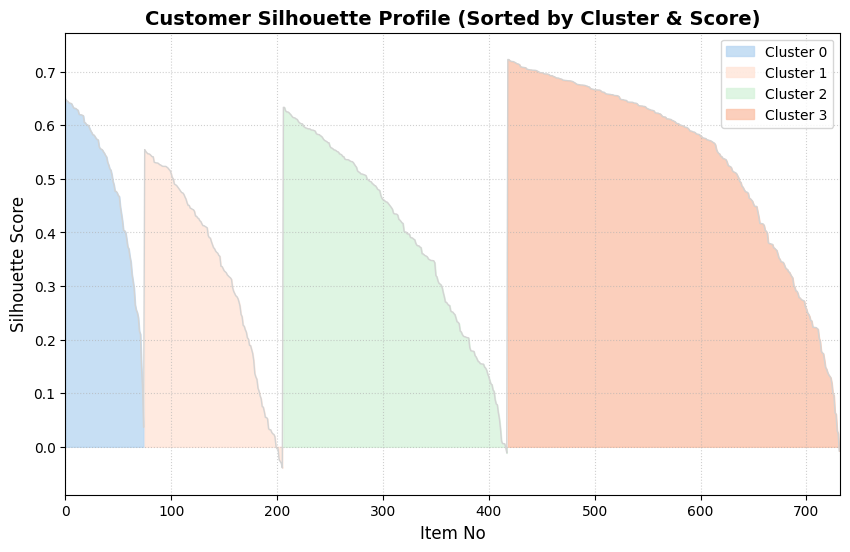

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples

# 1. & 2. 計算每個客戶的獨立輪廓值並新增為 'Sil_Score' 欄位
features = nrfm[['R_Norm', 'F_Norm', 'M_Norm']]
labels = nrfm['Cluster']
nrfm['Sil_Score'] = silhouette_samples(features, labels)

# 3. 關鍵排序步驟：先依 Cluster 升冪，再依 Sil_Score 降冪排序，並重設索引
nrfm_sorted = nrfm.sort_values(by=['Cluster', 'Sil_Score'], ascending=[True, False]).reset_index(drop=True)

# 4. 繪製個體輪廓值分佈圖
plt.figure(figsize=(10, 6))

# 設定四個群組對齊老師風格的粉嫩填滿顏色
colors = ['#bad7f2', '#ffe5d9', '#d8f3dc', '#fbc4ab']

x = np.arange(len(nrfm_sorted))
y = nrfm_sorted['Sil_Score']

# 繪製外框折線
plt.plot(x, y, color='lightgray', linewidth=1)

# 依據各群組索引區間使用 fill_between 進行著色
for cluster_id in sorted(nrfm_sorted['Cluster'].unique()):
    cluster_idx = nrfm_sorted[nrfm_sorted['Cluster'] == cluster_id].index
    plt.fill_between(
        x,
        y,
        0,
        where=(x >= cluster_idx.min()) & (x <= cluster_idx.max()),
        color=colors[cluster_id],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# 5. 細節調整與存檔
plt.xlim(0, len(nrfm_sorted))
plt.ylim(nrfm_sorted['Sil_Score'].min() - 0.05, nrfm_sorted['Sil_Score'].max() + 0.05)
plt.xlabel('Item No', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Customer Silhouette Profile (Sorted by Cluster & Score)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# 儲存圖片
plt.savefig('Teacher_Silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

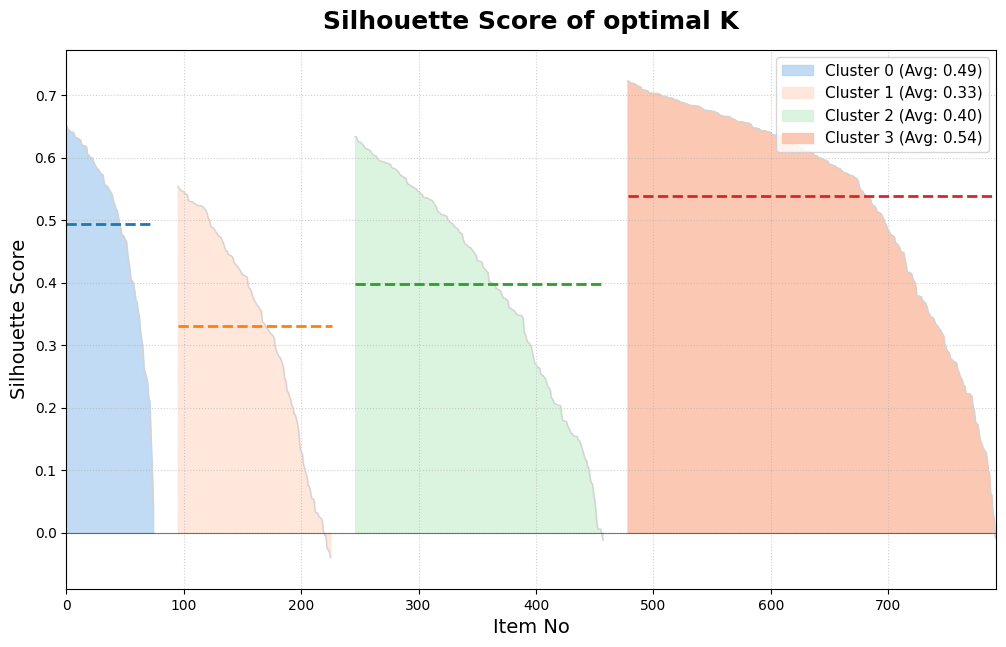

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. & 2. 計算每個客戶獨立的輪廓值
features = nrfm[['R_Norm', 'F_Norm', 'M_Norm']]
labels = nrfm['Cluster']
nrfm['Sil_Score'] = silhouette_samples(features, labels)

# 3. & 4. 準備繪圖參數與間隔邏輯
plt.figure(figsize=(12, 7))
pastel_colors = ['#bad7f2', '#ffe5d9', '#d8f3dc', '#fbc4ab']
darker_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

current_x_start = 0
gap = 20  # 群組之間的 X 軸間隔距離

for cluster_id in sorted(nrfm['Cluster'].unique()):
    # 篩選特定 Cluster 並依分數降冪排序
    cluster_data = nrfm[nrfm['Cluster'] == cluster_id].copy()
    cluster_data_sorted = cluster_data.sort_values(by='Sil_Score', ascending=False).reset_index(drop=True)

    # 計算該 Cluster 的平均輪廓分數
    cluster_avg = cluster_data_sorted['Sil_Score'].mean()

    # 設定當前群組的 X 座標軸範圍
    n_points = len(cluster_data_sorted)
    x_coords = np.arange(current_x_start, current_x_start + n_points)
    y_values = cluster_data_sorted['Sil_Score']

    # 繪製該群組的輪廓分數折線與區域填滿
    plt.plot(x_coords, y_values, color='lightgray', linewidth=1)
    plt.fill_between(
        x_coords,
        y_values,
        0,
        color=pastel_colors[cluster_id],
        alpha=0.9,
        label=f'Cluster {cluster_id} (Avg: {cluster_avg:.2f})'
    )

    # 在該群組專屬的 X 軸區間內，繪製對應組內平均線的水平虛線
    plt.hlines(
        y=cluster_avg,
        xmin=current_x_start,
        xmax=current_x_start + n_points,
        colors=darker_colors[cluster_id],
        linestyles='--',
        linewidth=2
    )

    # 更新下一個群組的起始 X 軸位置（加上 Gap 間隔）
    current_x_start += n_points + gap

# 5. 設定標題、標籤與存檔
plt.xlim(0, current_x_start - gap)
plt.ylim(nrfm['Sil_Score'].min() - 0.05, nrfm['Sil_Score'].max() + 0.05)
plt.title('Silhouette Score of optimal K', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Item No', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

# 存檔並顯示
plt.savefig('Teacher_Silhouette_Perfect.png', dpi=300, bbox_inches='tight')
plt.show()